In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score, classification_report

In [ ]:
# 1) Comece carregando e tratando a base de dados.
# Assim como na aula essa nova base não passou por pré processamento nenhum então nessa etapa, carrega os dados, verifique os tipos de dados, 
# verifique se temos dados faltantes e outliers.
# Quando necessário realize o tratamento.


In [2]:
base = pd.read_csv("C:/Users/user/Documents/EBAC/dados/CARDIO_BASE.csv", delimiter=';')

base.head(10)

,age,gender,height,weight,cholesterol,gluc,smoke,alco,active,cardio_disease
0,50,2,168,62,1,1,0,0,1,0
1,55,1,156,85,3,1,0,0,1,1
2,52,1,165,64,3,1,0,0,0,1
3,48,2,169,82,1,1,0,0,1,1
4,48,1,156,56,1,1,0,0,0,0
5,60,1,151,67,2,2,0,0,0,0
6,61,1,157,93,3,1,0,0,1,0
7,62,2,178,95,3,3,0,0,1,1
8,48,1,158,71,1,1,0,0,1,0
9,54,1,164,68,1,1,0,0,0,0


In [3]:
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             10000 non-null  int64 
 1   gender          10000 non-null  int64 
 2   height          10000 non-null  int64 
 3   weight          10000 non-null  object
 4   cholesterol     10000 non-null  int64 
 5   gluc            10000 non-null  int64 
 6   smoke           10000 non-null  int64 
 7   alco            10000 non-null  int64 
 8   active          10000 non-null  int64 
 9   cardio_disease  10000 non-null  int64 
dtypes: int64(9), object(1)
memory usage: 781.4+ KB


In [9]:
# Converter weight para float

base['weight'] = base['weight'].str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float)

In [10]:
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             10000 non-null  int64  
 1   gender          10000 non-null  int64  
 2   height          10000 non-null  int64  
 3   weight          10000 non-null  float64
 4   cholesterol     10000 non-null  int64  
 5   gluc            10000 non-null  int64  
 6   smoke           10000 non-null  int64  
 7   alco            10000 non-null  int64  
 8   active          10000 non-null  int64  
 9   cardio_disease  10000 non-null  int64  
dtypes: float64(1), int64(9)
memory usage: 781.4 KB


In [11]:
base.describe()

,age,gender,height,weight,cholesterol,gluc,smoke,alco,active,cardio_disease
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,53.288300,1.345400,164.308200,74.303710,1.365000,1.222200,0.089000,0.053700,0.797200,0.503100
std,6.796234,0.475522,8.178796,14.566353,0.677658,0.565561,0.284758,0.225436,0.402105,0.500015
min,30.000000,1.000000,70.000000,30.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,1.000000,159.000000,65.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,165.000000,72.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000
75%,58.000000,2.000000,170.000000,82.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,65.000000,2.000000,250.000000,200.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [12]:
# Não aparenta ter grande presença de outliers

In [ ]:
# 2) Agora é hora de explorar os dados com uma análise bem completa.
# Plote pelo menos 3 gráficos analisando o comportamento da variável cardio com outras variaveis da sua preferência (análise bivariada). 
# Não se esqueça de trazer insights acerca do analisado.


TypeError: Legend.__init__() got an unexpected keyword argument 'lavels'

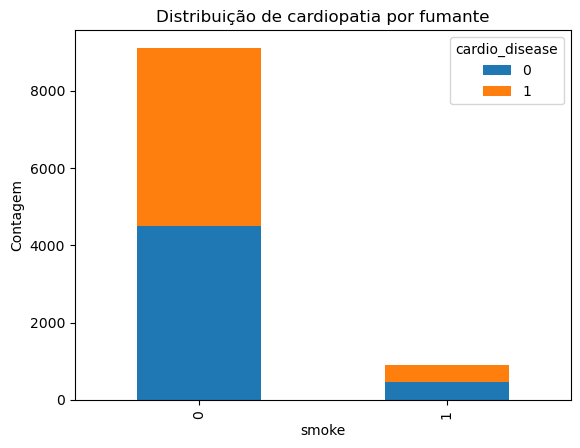

In [51]:
# breve analise bivariada para conhecermos melhor nossos dados 
contagem = pd.crosstab(base['smoke'], base['cardio_disease'])
contagem.plot(kind='bar', stacked=True)
plt.title('Distribuição de cardiopatia por fumante')
plt.xlabel('smoke')
plt.ylabel('Contagem')
plt.legend(title='cardio_disease', lavels=['1', '0'])
plt.show()

TypeError: Legend.__init__() got an unexpected keyword argument 'lavels'

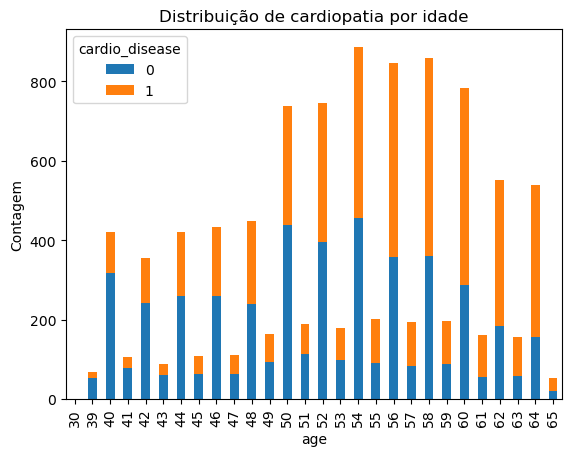

In [52]:
# breve analise bivariada para conhecermos melhor nossos dados 
contagem = pd.crosstab(base['age'], base['cardio_disease'])
contagem.plot(kind='bar', stacked=True)
plt.title('Distribuição de cardiopatia por idade')
plt.xlabel('age')
plt.ylabel('Contagem')
plt.legend(title='cardio_disease', lavels=['1', '0'])
plt.show()

TypeError: Legend.__init__() got an unexpected keyword argument 'lavels'

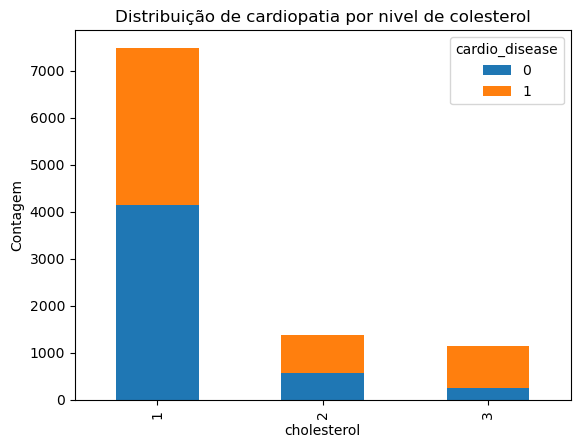

In [54]:
# breve analise bivariada para conhecermos melhor nossos dados 
contagem = pd.crosstab(base['cholesterol'], base['cardio_disease'])
contagem.plot(kind='bar', stacked=True)
plt.title('Distribuição de cardiopatia por nivel de colesterol')
plt.xlabel('cholesterol')
plt.ylabel('Contagem')
plt.legend(title='cardio_disease', lavels=['1', '0'])
plt.show()

In [ ]:
# podemos notar que nao existe forte correlacao entre positivos para fumante e cardiopa

In [13]:
# 3) Nessa etapa você deve trazer a matriz de correlação e apontar insights acerca das variáveis com um relacionamento mais forte entre si.

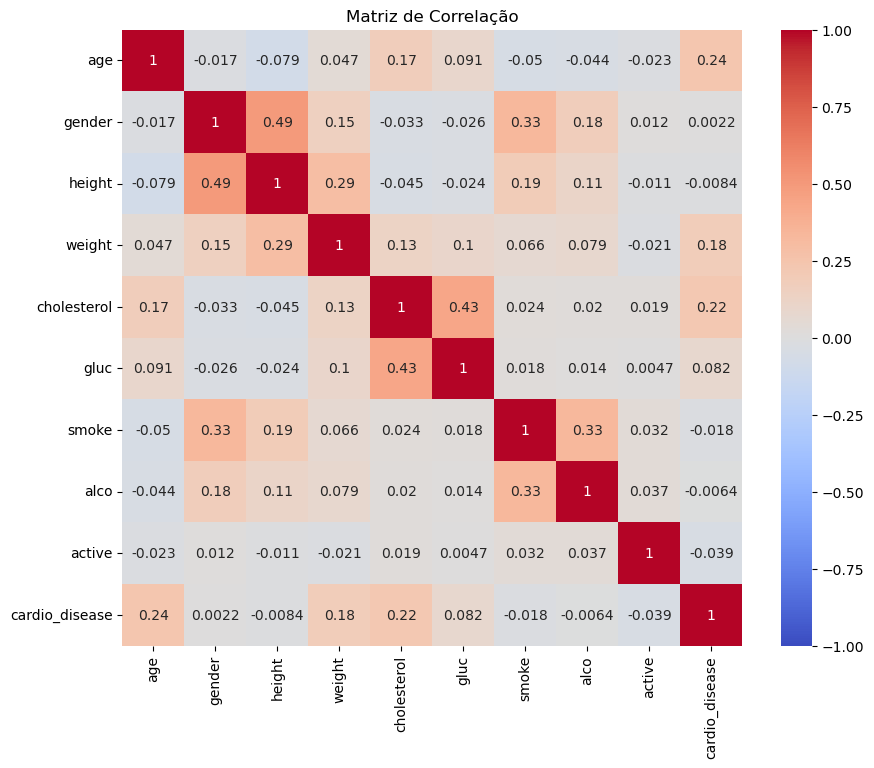

In [17]:
correlation_matrix = base.corr()

# plotando a matriz de correlação usando seaborn
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de Correlação')
plt.show()

In [ ]:
# Notamos uma correlação mais significativa apenas com as metricas de idade, colesterol e peso. 

In [16]:
# 4) Essa é a sua última etapa pré modelo. Você deve:

In [ ]:
# A) Separar a base em treino e teste.

In [18]:
# Separando em X (Variáveis de entrada) e Y (Variável de saída)

X = base.drop('cardio_disease', axis=1) # X contém todas as colunas, exceto 'cardio_disease'
Y = base['cardio_disease'] # Y contém apenas a coluna 'cardio_disease'

In [23]:
base['cardio_disease'].value_counts()

cardio_disease
1    5031
0    4969
Name: count, dtype: int64

In [21]:
# Separar em base de treino e teste (usando 80% para treino e 20% para teste)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [14]:
# B) Você considera que essa base precisa que os dados sejam padronizados? Se sim, porque? Se acredita que devem, então realize essa etapa.

In [ ]:
# Sim, pois Regressão logistica é um dos metodos de ML mais sensiveis a falta de padronização dos dados. Sendo assim, vamos padronizar os dados, ou melhor
# dizendo, vamos os tratá-los para possuriem escalas semelhantes, para assim ajudar na convergência mais fácil durante a etapa de treino.

In [24]:
# Inicializar StandardScaler
sc = StandardScaler()

# Ajustando e transformando os dados de treino
X_train = sc.fit_transform(X_train)

# Transformando os dados de teste usando os parâmetros aprendidos dos dados de treino
X_test = sc.transform(X_test)

In [15]:
# C) Verifique se os dados estão balanceados, se não, faça o balanceamento.

In [26]:
# Balanceando os dados de treinamento usando SMOTE

smote = SMOTE(random_state=42)
X_train_balanced, Y_train_balanced = smote.fit_resample(X_train, Y_train)

In [ ]:
# D) Visualize as bases de treino, teste (X E Y) e verifique se está tudo adequado.

In [27]:
X_train_balanced

array([[ 0.10037973, -0.73138185, -1.25610705, ..., -0.31328402,
        -0.24037742,  0.50780078],
       [-0.19393504,  1.36727483,  0.08809078, ..., -0.31328402,
        -0.24037742,  0.50780078],
       [ 1.4247962 , -0.73138185, -0.27850863, ..., -0.31328402,
        -0.24037742, -1.96927621],
       ...,
       [ 0.98332404,  1.36727483,  0.65429181, ..., -0.31328402,
        -0.24037742,  0.50780078],
       [-1.92199261,  1.36727483,  1.88967284, ...,  3.19199173,
        -0.24037742,  0.50780078],
       [-1.07687935, -0.73138185,  0.84528083, ..., -0.31328402,
        -0.24037742,  0.50780078]])

In [28]:
Y_train_balanced

0       0
1       0
2       1
3       1
4       0
       ..
8059    0
8060    0
8061    0
8062    0
8063    0
Name: cardio_disease, Length: 8064, dtype: int64

In [29]:
X_test

array([[-0.63540719, -0.73138185, -0.03410902, ..., -0.31328402,
        -0.24037742, -1.96927621],
       [ 0.10037973,  1.36727483,  1.43228861, ..., -0.31328402,
        -0.24037742,  0.50780078],
       [ 0.10037973, -0.73138185, -0.76730784, ..., -0.31328402,
        -0.24037742,  0.50780078],
       ...,
       [-1.66550889, -0.73138185,  0.6990898 , ..., -0.31328402,
        -0.24037742,  0.50780078],
       [-0.48824981, -0.73138185,  0.45469019, ..., -0.31328402,
        -0.24037742,  0.50780078],
       [ 1.27763881,  1.36727483, -0.03410902, ..., -0.31328402,
        -0.24037742,  0.50780078]])

In [30]:
Y_test

6252    0
4684    0
1731    1
4742    0
4521    1
       ..
6412    1
8285    1
7853    0
1095    1
6929    0
Name: cardio_disease, Length: 2000, dtype: int64

In [ ]:
# Todos os dados em X padronizados (entre 0 e 1) e os dados em Y variando entre 0 e 1

In [ ]:
# 5) Realize a etapa de treinamento do modelo:

In [ ]:
# A) Faça o treinamento do modelo.

In [31]:
# Iniciando treinamento

logistic_cardio = LogisticRegression(random_state = 0)
# poderiamos adicionar max_iter = um valoar. Ele controla o número máximo de vezes que o algoritmo itera sobre o conjunto de dados para encontrar 
# os melhores coeficientes

In [32]:
logistic_cardio.fit(X_train_balanced, Y_train_balanced)

LogisticRegression(random_state=0)

In [ ]:
# B) Traga o intercept e os coeficientes.

In [33]:
logistic_cardio.intercept_

array([0.01480688])

In [34]:
logistic_cardio.coef_

array([[ 0.44145989,  0.00861821, -0.07862685,  0.35097527,  0.40818199,
        -0.07356464, -0.02782615, -0.00872406, -0.07136021]])

In [ ]:
# c) Avalie as métricas do modelo treinado

In [ ]:
# Um valor correspondente a cada variavel

# todas padronizadas

# Etapa de treinamento concluida! sendo assim, podemos testar o modelo

In [ ]:
# D) Justifique se te parece que o modelo tem feito boas previsões ou não.

In [ ]:
# Sim, pois a padronizacao dos dados esta ok e isso é vital para o bom funcionamento do modelo de regressao logistica

In [ ]:
# 6) Teste seu modelo!

In [ ]:
# B) Avalie as métricas do modelo treinado

In [36]:
previsoes = logistic_cardio.predict(X_train_balanced)

In [37]:
relatorio = classification_report(Y_train_balanced, previsoes)
print('Relatório de Classificação:')
print(relatorio)

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.63      0.66      0.64      4032
           1       0.64      0.61      0.62      4032

    accuracy                           0.64      8064
   macro avg       0.64      0.64      0.63      8064
weighted avg       0.64      0.64      0.63      8064



In [ ]:
# o modelo motra-se promissor ao ter valores de 'precision' e 'recall' proximos um do outro

In [ ]:
# A) Aplique o modelo aos dados de teste.

In [38]:
Y_pred_test = logistic_cardio.predict(X_test)

In [39]:
relatorio = classification_report(Y_test, Y_pred_test)
print('Relatório de Classificação:')
print(relatorio)

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.65      0.70      0.67      1001
           1       0.67      0.61      0.64       999

    accuracy                           0.66      2000
   macro avg       0.66      0.66      0.66      2000
weighted avg       0.66      0.66      0.66      2000



In [ ]:
# C) Plote o gráfico da curva AUC-ROC e explique o que consegue analisar através do gráfico.

In [44]:
fpr, tpr, thresholds = roc_curve(Y_test, Y_pred_test)

# Calcular o AUC
roc_auc = roc_auc_score(Y_test, Y_pred_test)
print("AUC: {:.2f}".format(roc_auc))

AUC: 0.66


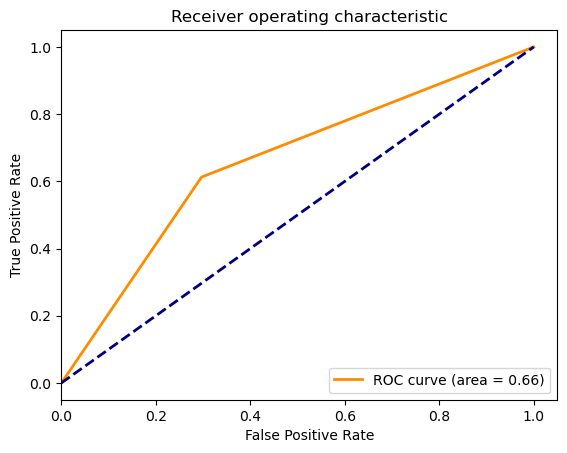

In [45]:
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.xlim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.show()

In [ ]:
# Assim como o modelo anterior, a curva ROC demonstra um acerto na casa dos 66%

In [ ]:
# 7) Explique:

In [ ]:
# A) Explique com suas palavras regressão logistica.

In [ ]:
# A regressão logística é um metodo computacional que te diz a chance de algo com duas opções acontecer, baseada em outros fatores que você conhece. 
# Ela usa uma matemática esperta para transformar esses fatores em uma probabilidade entre 0 e 1, ajudando você a tomar uma decisão de "sim" ou "não". 
# É uma ferramenta muito útil quando o resultado que você quer prever tem apenas duas possibilidades.

In [ ]:
# B) Explique porque a regressão logistica é um modelo de classificação.

In [ ]:
# a regressão logística utiliza uma função para estimar a probabilidade de uma observação pertencer a uma determinada categoria e, 
# com base nessa probabilidade e um limiar, realiza a classificação dessa observação em uma das categorias predefinidas.

In [ ]:
# C) Explique quais pontos em comum a regressão logistica tem da regressão linear.

In [ ]:
# Em resumo, ambas as regressões utilizam uma estrutura linear para modelar a relação entre variáveis, aprendem a partir de dados e dependem da 
# interpretação de seus coeficientes para entender essa relação. A principal diferença reside no tipo de variável dependente e na função de ligação 
# utilizada para adequar o modelo à natureza dessa variável.